# English–Amharic NMT Preprocessing Analysis

This notebook analyzes and verifies the output of the centralized preprocessing pipeline:

```text
src/nmt/data/clean.py


##  Imports

In [1]:
from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Imports completed.")

Imports completed.


### Locate project root and files

In [2]:
PROJECT_ROOT = Path.cwd()

# Support execution from either the project root or notebooks/ directory.
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "mt560_amharic_english"
    / "train.parquet"
)

CLEAN_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.parquet"
)

CLEAN_EN_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.en"
)

CLEAN_AM_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.am"
)

print("Project root:", PROJECT_ROOT)
print("Raw file    :", RAW_FILE)
print("Clean file  :", CLEAN_FILE)

if not RAW_FILE.exists():
    raise FileNotFoundError(f"Raw dataset not found: {RAW_FILE}")

if not CLEAN_FILE.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEAN_FILE}\n"
        "Run: python src/nmt/data/clean.py"
    )

print("\nAll required dataset files were found.")

Project root: c:\Users\olibe\Desktop\neural-machine-translation
Raw file    : c:\Users\olibe\Desktop\neural-machine-translation\data\raw\mt560_amharic_english\train.parquet
Clean file  : c:\Users\olibe\Desktop\neural-machine-translation\data\interim\mt560_amharic_english\train_clean.parquet

All required dataset files were found.


## 1. Load Raw and Cleaned Datasets

In [3]:
raw_df = pd.read_parquet(RAW_FILE)
clean_df = pd.read_parquet(CLEAN_FILE)

print(f"Raw dataset rows    : {len(raw_df):,}")
print(f"Cleaned dataset rows: {len(clean_df):,}")

print("\nRaw columns:")
print(raw_df.columns.tolist())

print("\nCleaned columns:")
print(clean_df.columns.tolist())

Raw dataset rows    : 669,145
Cleaned dataset rows: 662,491

Raw columns:
['eng', 'amh']

Cleaned columns:
['eng', 'amh']


In [4]:
print("Raw dataset sample:")
display(raw_df.head())

print("\nCleaned dataset sample:")
display(clean_df.head())

Raw dataset sample:


,eng,amh
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?



Cleaned dataset sample:


,eng,amh
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?


### Validate required columns

In [5]:
required_columns = {"eng", "amh"}

if not required_columns.issubset(raw_df.columns):
    raise ValueError(
        f"Raw dataset is missing columns: {required_columns - set(raw_df.columns)}"
    )

if not required_columns.issubset(clean_df.columns):
    raise ValueError(
        f"Cleaned dataset is missing columns: {required_columns - set(clean_df.columns)}"
    )

print("Both datasets contain the required columns:", sorted(required_columns))

Both datasets contain the required columns: ['amh', 'eng']


## 2. Dataset Size Comparison

### Compare row counts

In [6]:
raw_count = len(raw_df)
clean_count = len(clean_df)

removed_count = raw_count - clean_count
retention_percentage = clean_count / raw_count * 100
removal_percentage = removed_count / raw_count * 100

size_comparison = pd.DataFrame({
    "Dataset": ["Raw dataset", "Cleaned dataset"],
    "Number of pairs": [raw_count, clean_count],
})

display(size_comparison)

print(f"Removed pairs : {removed_count:,}")
print(f"Retention     : {retention_percentage:.2f}%")
print(f"Removal rate  : {removal_percentage:.2f}%")

,Dataset,Number of pairs
0,Raw dataset,669145
1,Cleaned dataset,662491


Removed pairs : 6,654
Retention     : 99.01%
Removal rate  : 0.99%


### Dataset size chart

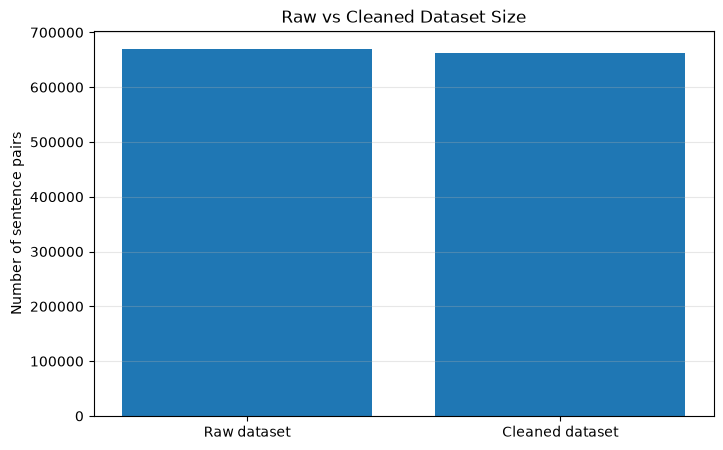

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Raw dataset", "Cleaned dataset"],
    [raw_count, clean_count]
)

plt.title("Raw vs Cleaned Dataset Size")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 3. Reproduce the Centralized Cleaning Report

The cleaning logic is imported from:

```text
src/nmt/data/clean.py

###  Import `clean_corpus`


In [9]:
pip install torch --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/125.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/125.9 MB 2.6 MB/s eta 0:00:49
   ---------------------------------------- 0.5/125.9 MB 2.6 MB/s eta 0:00:49
   ---------------------------------------- 0.8/125.9 MB 1.1 MB/s eta 0:01:59
   ---------------------------------------- 1.0/125.9 MB 988.9 kB/s eta 0:02:07
   ---------------------------------------- 1.0/125.9 MB 988.9 kB/s eta 0:02:07
   ---------------------------------------- 1.3/125.9 MB 948.8 kB/s eta 0:02:12
   ---------------------------------------- 1.6/125.9 MB 925.6 kB/s eta 0:02:15
   ---------------------------------------- 1.6/125.9 MB 925.6 kB/s eta 0:02:15
    --------------------------------------- 1.8/125.9 MB 908.5 kB/s eta 0:02:17
    --------------------------------------- 2.1/125.9 MB 900.5 kB/s eta 0:02:18
    --------------------------------------- 2.1/125.9 MB 900.5 kB/s eta 0:02:1

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # or wherever your root is
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from nmt.data.clean import clean_corpus
print("Successfully imported clean_corpus().")


Successfully imported clean_corpus().


### Reproduce cleaning report

In [12]:
raw_en = raw_df["eng"].fillna("").astype(str).tolist()
raw_am = raw_df["amh"].fillna("").astype(str).tolist()

_, _, cleaning_report = clean_corpus(
    raw_en,
    raw_am,
    min_len=2,
    max_len=100,
    remove_duplicates=True,
)

cleaning_report_df = pd.DataFrame(
    list(cleaning_report.items()),
    columns=["Metric", "Count"]
)

display(cleaning_report_df)

,Metric,Count
0,original,669145
1,removed_empty,0
2,removed_urls,202
3,removed_length,3798
4,removed_script,2603
5,removed_dups,51
6,final,662491


### Display detailed cleaning report

In [13]:
original = cleaning_report["original"]
final = cleaning_report["final"]

total_removed_from_report = original - final
reported_retention = final / original * 100
reported_removal_rate = total_removed_from_report / original * 100

print("CLEANING REPORT")
print("-" * 60)
print(f"Original pairs                  : {cleaning_report['original']:,}")
print(f"Removed — empty                 : {cleaning_report['removed_empty']:,}")
print(f"Removed — URLs                  : {cleaning_report['removed_urls']:,}")
print(f"Removed — length filter         : {cleaning_report['removed_length']:,}")
print(f"Removed — no Ethiopic script   : {cleaning_report['removed_script']:,}")
print(f"Removed — exact duplicates      : {cleaning_report['removed_dups']:,}")
print(f"Total removed                   : {total_removed_from_report:,}")
print(f"Final clean pairs               : {final:,}")
print(f"Retention rate                  : {reported_retention:.2f}%")
print(f"Removal rate                    : {reported_removal_rate:.2f}%")

CLEANING REPORT
------------------------------------------------------------
Original pairs                  : 669,145
Removed — empty                 : 0
Removed — URLs                  : 202
Removed — length filter         : 3,798
Removed — no Ethiopic script   : 2,603
Removed — exact duplicates      : 51
Total removed                   : 6,654
Final clean pairs               : 662,491
Retention rate                  : 99.01%
Removal rate                    : 0.99%


### Verify saved dataset against cleaning report

In [14]:
assert cleaning_report["original"] == len(raw_df), (
    "The report's original count does not match the raw dataset."
)

assert cleaning_report["final"] == len(clean_df), (
    "The cleaning report's final count does not match the saved cleaned dataset."
)

print("Cleaning report and saved cleaned dataset match.")
print(f"Verified final pair count: {len(clean_df):,}")

Cleaning report and saved cleaned dataset match.
Verified final pair count: 662,491


## 4. Cleaning Impact Summary

In [15]:
impact_data = [
    ["Original pairs", cleaning_report["original"], 0.0],
    ["Removed — empty", cleaning_report["removed_empty"], 0.0],
    ["Removed — URLs", cleaning_report["removed_urls"], 0.0],
    ["Removed — length filter", cleaning_report["removed_length"], 0.0],
    ["Removed — no Ethiopic script", cleaning_report["removed_script"], 0.0],
    ["Removed — exact duplicates", cleaning_report["removed_dups"], 0.0],
    ["Final clean pairs", cleaning_report["final"], 0.0],
]

impact_df = pd.DataFrame(
    impact_data,
    columns=["Cleaning stage", "Number of pairs", "Percentage of original"]
)

impact_df["Percentage of original"] = (
    impact_df["Number of pairs"] / cleaning_report["original"] * 100
).round(4)

display(impact_df)

,Cleaning stage,Number of pairs,Percentage of original
0,Original pairs,669145,100.0000
1,Removed — empty,0,0.0000
2,Removed — URLs,202,0.0302
3,Removed — length filter,3798,0.5676
4,Removed — no Ethiopic script,2603,0.3890
5,Removed — exact duplicates,51,0.0076
6,Final clean pairs,662491,99.0056


### Removed-pair breakdown chart

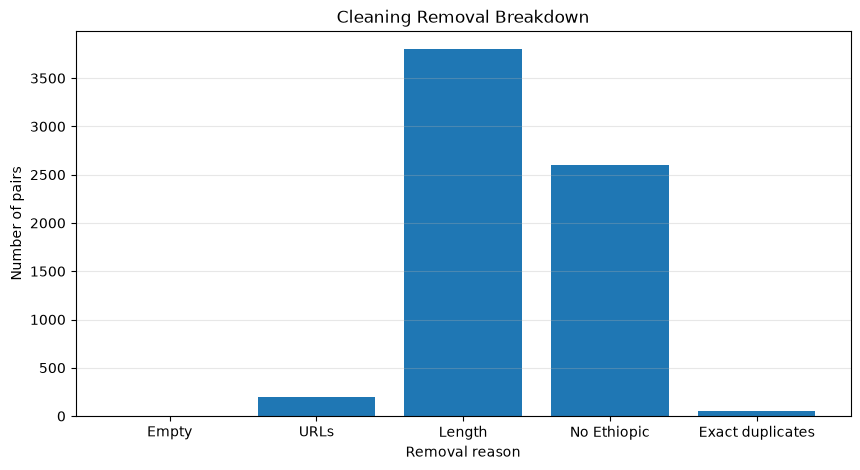

In [16]:
removal_labels = [
    "Empty",
    "URLs",
    "Length",
    "No Ethiopic",
    "Exact duplicates",
]

removal_values = [
    cleaning_report["removed_empty"],
    cleaning_report["removed_urls"],
    cleaning_report["removed_length"],
    cleaning_report["removed_script"],
    cleaning_report["removed_dups"],
]

plt.figure(figsize=(10, 5))

plt.bar(removal_labels, removal_values)

plt.title("Cleaning Removal Breakdown")
plt.xlabel("Removal reason")
plt.ylabel("Number of pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Sentence-Length Comparison

The same whitespace-based word-count method is used for both datasets.

In [17]:
def add_length_columns(dataframe):
    result = dataframe[["eng", "amh"]].copy()

    result["eng_word_count"] = (
        result["eng"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    result["amh_word_count"] = (
        result["amh"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    return result


raw_lengths = add_length_columns(raw_df)
clean_lengths = add_length_columns(clean_df)

print("Length columns created.")

Length columns created.


### Before-and-after length statistics

In [18]:
length_comparison = pd.DataFrame({
    "Raw English": raw_lengths["eng_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Cleaned English": clean_lengths["eng_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Raw Amharic": raw_lengths["amh_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Cleaned Amharic": clean_lengths["amh_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
})

display(length_comparison.round(2))

,Raw English,Cleaned English,Raw Amharic,Cleaned Amharic
count,669145.00,662491.00,669145.00,662491.00
mean,21.41,21.53,14.59,14.67
std,12.19,11.99,8.62,8.45
min,1.00,2.00,1.00,2.00
50%,19.00,19.00,13.00,13.00
75%,28.00,28.00,18.00,18.00
90%,37.00,37.00,25.00,25.00
95%,44.00,44.00,30.00,30.00
99%,61.00,60.00,44.00,44.00
max,120.00,100.00,118.00,100.00


### Compare English distributions

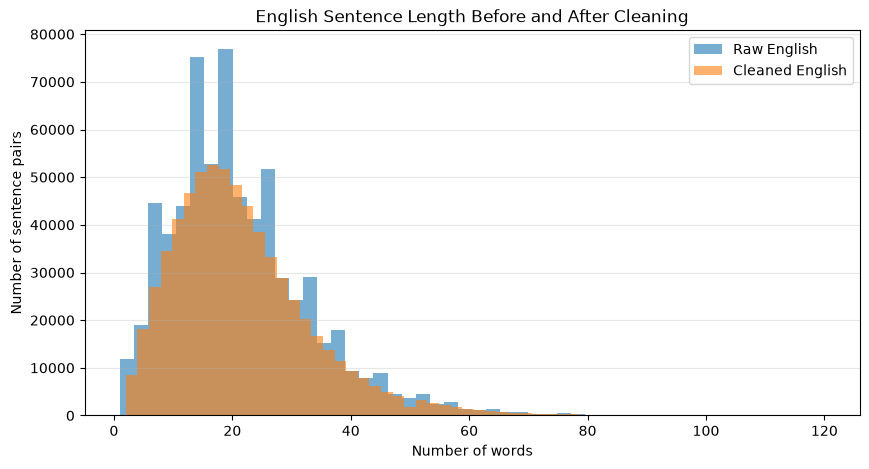

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    raw_lengths["eng_word_count"],
    bins=50,
    alpha=0.6,
    label="Raw English"
)

plt.hist(
    clean_lengths["eng_word_count"],
    bins=50,
    alpha=0.6,
    label="Cleaned English"
)

plt.title("English Sentence Length Before and After Cleaning")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Compare Amharic distributions

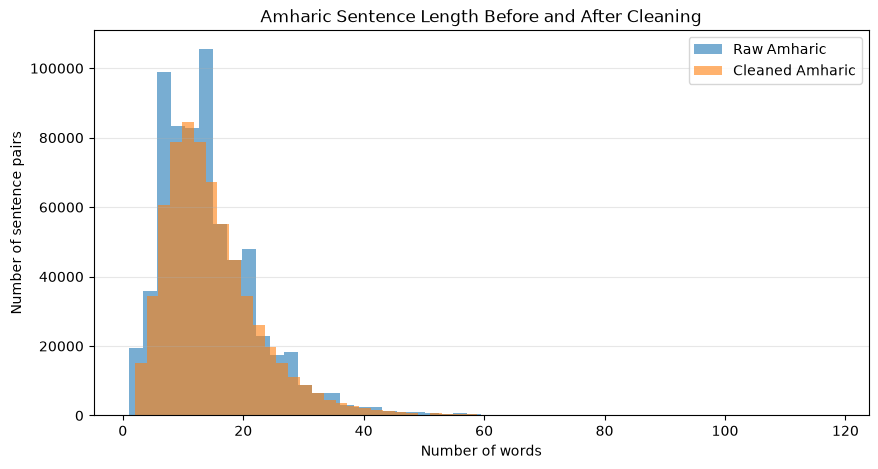

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    raw_lengths["amh_word_count"],
    bins=50,
    alpha=0.6,
    label="Raw Amharic"
)

plt.hist(
    clean_lengths["amh_word_count"],
    bins=50,
    alpha=0.6,
    label="Cleaned Amharic"
)

plt.title("Amharic Sentence Length Before and After Cleaning")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Verify final length bounds

In [21]:
MIN_LENGTH = 2
MAX_LENGTH = 100

clean_english_outside_bounds = (
    (clean_lengths["eng_word_count"] < MIN_LENGTH) |
    (clean_lengths["eng_word_count"] > MAX_LENGTH)
)

clean_amharic_outside_bounds = (
    (clean_lengths["amh_word_count"] < MIN_LENGTH) |
    (clean_lengths["amh_word_count"] > MAX_LENGTH)
)

print(
    "Cleaned English sentences outside bounds:",
    clean_english_outside_bounds.sum()
)

print(
    "Cleaned Amharic sentences outside bounds:",
    clean_amharic_outside_bounds.sum()
)

assert clean_english_outside_bounds.sum() == 0
assert clean_amharic_outside_bounds.sum() == 0

print("Length-bound verification passed.")

Cleaned English sentences outside bounds: 0
Cleaned Amharic sentences outside bounds: 0
Length-bound verification passed.


## 6. URL Verification

The cleaning pipeline removes any pair containing a URL in either the English or Amharic sentence.

In [22]:
URL_RE = re.compile(
    r"(?:https?://|www\.)\S+",
    flags=re.IGNORECASE,
)

clean_url_in_english = clean_df["eng"].fillna("").astype(str).apply(
    lambda text: bool(URL_RE.search(text))
)

clean_url_in_amharic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(URL_RE.search(text))
)

clean_url_mask = clean_url_in_english | clean_url_in_amharic

url_verification = pd.DataFrame({
    "Count": [
        clean_url_in_english.sum(),
        clean_url_in_amharic.sum(),
        clean_url_mask.sum(),
    ],
}, index=[
    "URLs in English",
    "URLs in Amharic",
    "URL-containing pairs",
])

display(url_verification)

assert clean_url_mask.sum() == 0

print("URL-removal verification passed.")

,Count
URLs in English,0
URLs in Amharic,0
URL-containing pairs,0


URL-removal verification passed.


## 7. Ethiopic-Script Verification

The cleaning pipeline requires at least one Ethiopic character in every Amharic target sentence.

In [23]:
ETHIOPIC_RE = re.compile(r"[\u1200-\u137F]")

clean_has_ethiopic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(ETHIOPIC_RE.search(text))
)

ethiopic_verification = pd.DataFrame({
    "Count": [
        clean_has_ethiopic.sum(),
        (~clean_has_ethiopic).sum(),
    ],
}, index=[
    "Targets containing Ethiopic characters",
    "Targets without Ethiopic characters",
])

display(ethiopic_verification)

assert (~clean_has_ethiopic).sum() == 0

print("Ethiopic-script verification passed.")

,Count
Targets containing Ethiopic characters,662491
Targets without Ethiopic characters,0


Ethiopic-script verification passed.


## 8. Missing and Empty-Value Verification

In [24]:
clean_eng_text = clean_df["eng"].fillna("").astype(str)
clean_amh_text = clean_df["amh"].fillna("").astype(str)

missing_empty_verification = pd.DataFrame({
    "Missing values": [
        clean_df["eng"].isna().sum(),
        clean_df["amh"].isna().sum(),
    ],
    "Empty or whitespace-only values": [
        clean_eng_text.str.strip().eq("").sum(),
        clean_amh_text.str.strip().eq("").sum(),
    ],
}, index=["English", "Amharic"])

display(missing_empty_verification)

assert clean_df["eng"].isna().sum() == 0
assert clean_df["amh"].isna().sum() == 0
assert clean_eng_text.str.strip().eq("").sum() == 0
assert clean_amh_text.str.strip().eq("").sum() == 0

print("Missing-value and empty-string verification passed.")

,Missing values,Empty or whitespace-only values
English,0,0
Amharic,0,0


Missing-value and empty-string verification passed.


## 9. Exact-Duplicate Verification

In [25]:
exact_duplicate_count_clean = clean_df.duplicated(
    subset=["eng", "amh"]
).sum()

print(f"Exact duplicate pairs in cleaned dataset: {exact_duplicate_count_clean:,}")

assert exact_duplicate_count_clean == 0

print("Exact-duplicate verification passed.")

Exact duplicate pairs in cleaned dataset: 0
Exact-duplicate verification passed.


## 10. Markup Verification

The cleaning pipeline removes recognized HTML-like tags such as `<p>`, `<br>`, `<div>`, `<span>`, and similar tags.

This check reports remaining angle-bracket patterns for manual inspection. It is not used as an automatic failure condition because angle brackets may occur as legitimate punctuation or content.

In [26]:
HTML_TAG_RE = re.compile(r"<[^>]+>")

remaining_markup_in_english = clean_df["eng"].fillna("").astype(str).apply(
    lambda text: bool(HTML_TAG_RE.search(text))
)

remaining_markup_in_amharic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(HTML_TAG_RE.search(text))
)

remaining_markup_mask = (
    remaining_markup_in_english |
    remaining_markup_in_amharic
)

print(
    "Cleaned pairs containing remaining angle-bracket patterns:",
    remaining_markup_mask.sum()
)

if remaining_markup_mask.sum() > 0:
    display(
        clean_df.loc[
            remaining_markup_mask,
            ["eng", "amh"]
        ].head(20)
    )
else:
    print("No remaining angle-bracket patterns were found.")

Cleaned pairs containing remaining angle-bracket patterns: 115


,eng,amh
18175,"< < For the Chief Musician . For a stringed instrument . By David . > > Hear my cry , God . Listen to my prayer .",አምላክ ሆይ ፥ ልመናዬን ስማ ፥ ጸሎቴንም አድምጥ ።
21130,"< < For the Chief Musician . To the tune of "" Do Not Destroy . "" A poem by David . > > Do you indeed speak righteousness , silent ones ? Do you judge blamelessly , you sons of men ?",በእውነት ጽድቅን ብትናገሩስ ፥ የሰው ልጆች ሆይ ፥ በቅን ትፈርዳላችሁ ፤
22102,< < A Psalm by David . > > Yahweh is my shepherd : I shall lack nothing .,እግዚአብሔር እረኛዬ ነው ፥ የሚያሳጣኝም የለም ።
29410,"< < A Psalm by David . > > Ascribe to Yahweh , you sons of the mighty , ascribe to Yahweh glory and strength .",የአምላክ ልጆች ሆይ ፥ ለእግዚአብሔር አምጡ ። ክብርንና ምስጋናን ለእግዚአብሔር አምጡ ።
30429,"< < A Psalm . > > Sing to Yahweh a new song , for he has done marvelous things ! His right hand , and his holy arm , have worked salvation for him .",ለእግዚአብሔር አዲስ ምስጋናን አመስግኑ ፥ እግዚአብሔር ተኣምራትን አድርጎአልና ፤ ቀኙ የተቀደሰም ክንዱ ለእርሱ ማዳን አደረገ ።
41598,"< < A Psalm by David . > > Yahweh , who shall dwell in your sanctuary ? Who shall live on your holy hill ?",አቤቱ ፥ በድንኳንህ ውስጥ ማን ያድራል ? በተቀደሰውም ተራራህ ማን ይኖራል ?
48162,"< < A contemplation by Asaph . > > God , why have you rejected us forever ? Why does your anger smolder against the sheep of your pasture ?",አቤቱ ፥ ስለ ምን ለዘወትር ጣልኸኝ ? በማሰማርያህ በጎች ላይስ ቍጣህን ስለ ምን ተቈጣህ ?
61217,"< < For the Chief Musician . A Psalm by the sons of Korah . > > Oh clap your hands , all you nations . Shout to God with the voice of triumph !",አሕዛብ ሁላችሁ ፥ እጆቻችሁን አጨብጭቡ ፥ በደስታ ቃልም ለእግዚአብሔር እልል በሉ ።
61282,"< < For the Chief Musician . To the tune of "" Lilies . "" By David . > > Save me , God , for the waters have come up to my neck !",አቤቱ ፥ ውኃ እስከ ነፍሴ ደርሶብኛልና አድነኝ ።
73018,"--description < description \ _ BAR _ file > , -D < description \ _ BAR _ file > Provide a descriptive name for the command to be used in the default message , making it nicer . You can also provi...","--መግለጫ < description \ _ BAR _ file > , -መ < description \ _ BAR _ file > ማቅረብ መግለጫ ስም ለትእዛዙ እንዲጠቀምበት በነበረው መልእክት , ጥሩ እንዲያደርገው . እንዲሁም ማቅረብ ይችላሉ ሁሉንም መንገድ ለዴስክቶፕ ፋይል . ቁልፍ ስምን ይጠቀማል በዚህ ሁኔታ"


## 11. Inspect Cleaned Translation Pairs

In [27]:
clean_sample = clean_df[["eng", "amh"]].sample(
    n=min(10, len(clean_df)),
    random_state=42
).reset_index(drop=True)

display(clean_sample)

,eng,amh
0,"We must be on guard and never drift downhill , back into the world , perhaps to be choked spiritually .",ከፍ ካለው የንጹሕ አምልኮ ስፍራ ተንሸራትተን ወደ ታች በመውረድ ዓለም ውስጥ ገብተን በመንፈሳዊ ታፍነን እንዳንሞት ልንጠነቀቅ ይገባል ።
1,"Mom had to work continually to make ends meet , leaving my sister and me with neighbors after school .",በዚህ ምክንያት በአንድ ወላጅ ብቻ የምንተዳደር ቤተሰቦች ሆንን ።
2,"The world may view angry behavior as normal , but it dishonors our Creator .",የሚያሳዝነው እንዲህ ያለው ምግባር አብዛኛውን ጊዜ ወደ ጠብ ይመራል ።
3,Repentant King Manasseh may have taught Josiah about God 's mercy .,ንጉሥ ምናሴ ንስሐ ከገባ በኋላ ኢዮስያስን ስለ አምላክ ምሕረት አስተምሮት ሊሆን ይችላል ።
4,( b ) Give examples to show the damage that the tongue can do .,( ለ ) አንደበት ጉዳት ሊያስከትል እንደሚችል የሚያሳዩ ምሳሌዎችን ጥቀስ ።
5,"For example , he made generous contributions toward the construction of Jehovah 's temple .",ለምሳሌ ያህል ፣ የይሖዋን ቤተ መቅደስ ግንባታ ለመደገፍ ከፍተኛ መዋጮ አድርጓል ።
6,Jesus said that many are on a road leading to destruction .,ኢየሱስ ብዙዎች ወደ ጥፋት በሚመራ መንገድ ላይ እየተጓዙ እንደሆነ ተናግሯል ።
7,I had two dogs - one named Vulkan and the other Palma . Palma was a faithful companion for many years .,ሁለት ውሻዎች የነበሩኝ ሲሆን አንደኛው ቩልካን ሌላዋ ደግሞ ፓልማ ይባሉ ነበር ።
8,"But God made him extraordinarily strong . ""","ሆኖም አምላክ ልዩ የሆነ ብርታት ሰጥቶታል ። """
9,Do those who do evil imagine that they will escape Us ? How ill they judge !,ይልቁንም እነዚያ መጥፎዎችን ሥራዎች የሚሠሩት ሊያመልጡን ይጠረጥራሉን ያ የሚፈርዱት ( ፍርድ ) ከፋ ፡ ፡


## 12. Verify the Parallel Text Files

The cleaning script also writes:

- `train_clean.en`
- `train_clean.am`

Each line should correspond to one row in the cleaned Parquet file.

### Verify .en and .am files

In [28]:
if not CLEAN_EN_FILE.exists():
    raise FileNotFoundError(f"English text file not found: {CLEAN_EN_FILE}")

if not CLEAN_AM_FILE.exists():
    raise FileNotFoundError(f"Amharic text file not found: {CLEAN_AM_FILE}")

clean_en_lines = CLEAN_EN_FILE.read_text(encoding="utf-8").splitlines()
clean_am_lines = CLEAN_AM_FILE.read_text(encoding="utf-8").splitlines()

print(f"Cleaned Parquet rows : {len(clean_df):,}")
print(f"English text lines   : {len(clean_en_lines):,}")
print(f"Amharic text lines   : {len(clean_am_lines):,}")

assert len(clean_en_lines) == len(clean_df)
assert len(clean_am_lines) == len(clean_df)

print("Parallel text-file line counts match the cleaned Parquet dataset.")

Cleaned Parquet rows : 662,491
English text lines   : 662,491
Amharic text lines   : 662,491
Parallel text-file line counts match the cleaned Parquet dataset.


### Verify text-file content

In [29]:
parquet_en = clean_df["eng"].astype(str).tolist()
parquet_am = clean_df["amh"].astype(str).tolist()

assert clean_en_lines == parquet_en
assert clean_am_lines == parquet_am

print("The `.en` and `.am` files exactly match the cleaned Parquet content.")

The `.en` and `.am` files exactly match the cleaned Parquet content.


## 13. Final Preprocessing Summary

In [30]:
final_summary = {
    "Raw sentence pairs": len(raw_df),
    "Cleaned sentence pairs": len(clean_df),
    "Removed sentence pairs": len(raw_df) - len(clean_df),
    "Retention percentage": round(len(clean_df) / len(raw_df) * 100, 2),
    "Removed URL pairs": cleaning_report["removed_urls"],
    "Removed length-invalid pairs": cleaning_report["removed_length"],
    "Removed non-Ethiopic targets": cleaning_report["removed_script"],
    "Removed exact duplicates": cleaning_report["removed_dups"],
    "Remaining missing values": int(clean_df[["eng", "amh"]].isna().sum().sum()),
    "Remaining empty values": int(
        clean_eng_text.str.strip().eq("").sum()
        + clean_amh_text.str.strip().eq("").sum()
    ),
    "Remaining URL pairs": int(clean_url_mask.sum()),
    "Remaining exact duplicates": int(exact_duplicate_count_clean),
    "English sentences outside length bounds": int(clean_english_outside_bounds.sum()),
    "Amharic sentences outside length bounds": int(clean_amharic_outside_bounds.sum()),
    "Targets without Ethiopic characters": int((~clean_has_ethiopic).sum()),
}

final_summary_df = pd.DataFrame(
    list(final_summary.items()),
    columns=["Metric", "Value"]
)

display(final_summary_df)

,Metric,Value
0,Raw sentence pairs,669145.00
1,Cleaned sentence pairs,662491.00
2,Removed sentence pairs,6654.00
3,Retention percentage,99.01
4,Removed URL pairs,202.00
5,Removed length-invalid pairs,3798.00
6,Removed non-Ethiopic targets,2603.00
7,Removed exact duplicates,51.00
8,Remaining missing values,0.00
9,Remaining empty values,0.00


## 14. Final Preprocessing Decision

The cleaned corpus is considered ready for the next stage when:

- The saved cleaned row count matches the centralized cleaning report.
- No missing or empty source-target values remain.
- No URL-containing pairs remain.
- No exact duplicate translation pairs remain.
- All sentence lengths are between 2 and 100 words.
- Every Amharic target contains at least one Ethiopic character.
- The `.en` and `.am` files match the cleaned Parquet dataset exactly.

The next stage is:

1. Train/validation/test splitting
2. Tokenization
3. Vocabulary construction
4. Dataset preparation for the baseline Seq2Seq model

# Train/Validation/Test Split

### We will first implement the split utility in:

''src/nmt/data/split.py''

#### The split will:

- Use the cleaned Parquet file.

- Preserve English–Amharic alignment.

- Create an 80% train / 10% validation / 10% test split.

- Use a fixed random seed of 42.

- Save both Parquet files and parallel .en / .am files.

- Verify that no exact translation pairs overlap between splits.

### Imports

In [31]:
from pathlib import Path

import pandas as pd
from IPython.display import display

### Locate the project root

In [32]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists() and (
    PROJECT_ROOT.parent / "data"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('c:/Users/olibe/Desktop/neural-machine-translation')

### Define paths

In [33]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mt560_amharic_english"
)

TRAIN_FILE = PROCESSED_DIR / "train.parquet"
VALIDATION_FILE = PROCESSED_DIR / "validation.parquet"
TEST_FILE = PROCESSED_DIR / "test.parquet"

TRAIN_EN_FILE = PROCESSED_DIR / "train.en"
TRAIN_AM_FILE = PROCESSED_DIR / "train.am"

VALIDATION_EN_FILE = PROCESSED_DIR / "validation.en"
VALIDATION_AM_FILE = PROCESSED_DIR / "validation.am"

TEST_EN_FILE = PROCESSED_DIR / "test.en"
TEST_AM_FILE = PROCESSED_DIR / "test.am"

### Check files exist

In [34]:
required_files = [
    TRAIN_FILE,
    VALIDATION_FILE,
    TEST_FILE,
    TRAIN_EN_FILE,
    TRAIN_AM_FILE,
    VALIDATION_EN_FILE,
    VALIDATION_AM_FILE,
    TEST_EN_FILE,
    TEST_AM_FILE,
]

file_status = pd.DataFrame(
    {
        "file": [str(path.relative_to(PROJECT_ROOT)) for path in required_files],
        "exists": [path.exists() for path in required_files],
    }
)

display(file_status)

assert file_status["exists"].all(), "One or more split files are missing."

,file,exists
0,data\processed\mt560_amharic_english\train.parquet,True
1,data\processed\mt560_amharic_english\validation.parquet,True
2,data\processed\mt560_amharic_english\test.parquet,True
3,data\processed\mt560_amharic_english\train.en,True
4,data\processed\mt560_amharic_english\train.am,True
5,data\processed\mt560_amharic_english\validation.en,True
6,data\processed\mt560_amharic_english\validation.am,True
7,data\processed\mt560_amharic_english\test.en,True
8,data\processed\mt560_amharic_english\test.am,True


### Load all splits

In [35]:
train_df = pd.read_parquet(TRAIN_FILE)
validation_df = pd.read_parquet(VALIDATION_FILE)
test_df = pd.read_parquet(TEST_FILE)

print("Train shape      :", train_df.shape)
print("Validation shape :", validation_df.shape)
print("Test shape       :", test_df.shape)

Train shape      : (529992, 2)
Validation shape : (66249, 2)
Test shape       : (66250, 2)


### Verify columns

In [36]:
expected_columns = ["eng", "amh"]

assert list(train_df.columns) == expected_columns
assert list(validation_df.columns) == expected_columns
assert list(test_df.columns) == expected_columns

print("Column checks passed.")

Column checks passed.


### Verify total row count

In [37]:
total_rows = (
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

print("Total split rows:", f"{total_rows:,}")

assert total_rows == 662_491

Total split rows: 662,491


### Display split proportions

In [38]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
    }
)

split_summary["percentage"] = (
    split_summary["rows"] / total_rows * 100
).round(2)

display(split_summary)

,split,rows,percentage
0,train,529992,80.0
1,validation,66249,10.0
2,test,66250,10.0


### Verify missing and empty values

In [39]:
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    assert split_df["eng"].isna().sum() == 0
    assert split_df["amh"].isna().sum() == 0

    assert (split_df["eng"].str.strip() != "").all()
    assert (split_df["amh"].str.strip() != "").all()

    print(f"{split_name}: missing and empty checks passed.")

train: missing and empty checks passed.
validation: missing and empty checks passed.
test: missing and empty checks passed.


### Verify exact duplicates within each split

In [40]:
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    duplicate_count = split_df.duplicated(
        subset=["eng", "amh"]
    ).sum()

    print(f"{split_name}: duplicate pairs =", duplicate_count)

    assert duplicate_count == 0

train: duplicate pairs = 0
validation: duplicate pairs = 0
test: duplicate pairs = 0


### Verify no cross-split leakage

In [41]:
train_pairs = set(zip(train_df["eng"], train_df["amh"]))

validation_pairs = set(
    zip(validation_df["eng"], validation_df["amh"])
)

test_pairs = set(zip(test_df["eng"], test_df["amh"]))

train_validation_overlap = train_pairs & validation_pairs
train_test_overlap = train_pairs & test_pairs
validation_test_overlap = validation_pairs & test_pairs

print("Train/Validation overlap:", len(train_validation_overlap))
print("Train/Test overlap      :", len(train_test_overlap))
print("Validation/Test overlap :", len(validation_test_overlap))

assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0

Train/Validation overlap: 0
Train/Test overlap      : 0
Validation/Test overlap : 0


### Verify parallel .en and .am files

In [44]:
parallel_files = {
    "train": (TRAIN_EN_FILE, TRAIN_AM_FILE, train_df),
    "validation": (
        VALIDATION_EN_FILE,
        VALIDATION_AM_FILE,
        validation_df,
    ),
    "test": (TEST_EN_FILE, TEST_AM_FILE, test_df),
}

for split_name, (en_file, am_file, split_df) in parallel_files.items():
    en_lines = en_file.read_text(encoding="utf-8").splitlines()
    am_lines = am_file.read_text(encoding="utf-8").splitlines()

    assert len(en_lines) == len(split_df)
    assert len(am_lines) == len(split_df)
    assert len(en_lines) == len(am_lines)

    assert en_lines == split_df["eng"].tolist()
    assert am_lines == split_df["amh"].tolist()

    print(f"{split_name}: parallel-file alignment passed.")

train: parallel-file alignment passed.
validation: parallel-file alignment passed.
test: parallel-file alignment passed.


### Inspect examples

In [45]:
print("TRAIN EXAMPLES")
display(train_df.head(5))

print("VALIDATION EXAMPLES")
display(validation_df.head(5))

print("TEST EXAMPLES")
display(test_df.head(5))

TRAIN EXAMPLES


,eng,amh
0,"We must be on guard and never drift downhill , back into the world , perhaps to be choked spiritually .",ከፍ ካለው የንጹሕ አምልኮ ስፍራ ተንሸራትተን ወደ ታች በመውረድ ዓለም ውስጥ ገብተን በመንፈሳዊ ታፍነን እንዳንሞት ልንጠነቀቅ ይገባል ።
1,"Mom had to work continually to make ends meet , leaving my sister and me with neighbors after school .",በዚህ ምክንያት በአንድ ወላጅ ብቻ የምንተዳደር ቤተሰቦች ሆንን ።
2,"The world may view angry behavior as normal , but it dishonors our Creator .",የሚያሳዝነው እንዲህ ያለው ምግባር አብዛኛውን ጊዜ ወደ ጠብ ይመራል ።
3,Repentant King Manasseh may have taught Josiah about God 's mercy .,ንጉሥ ምናሴ ንስሐ ከገባ በኋላ ኢዮስያስን ስለ አምላክ ምሕረት አስተምሮት ሊሆን ይችላል ።
4,( b ) Give examples to show the damage that the tongue can do .,( ለ ) አንደበት ጉዳት ሊያስከትል እንደሚችል የሚያሳዩ ምሳሌዎችን ጥቀስ ።


VALIDATION EXAMPLES


,eng,amh
0,The family still maintained a grasp of the parents ' mother tongue and reaped rich rewards .,ያም ሆኖ ቤተሰቡ በትውልድ ቋንቋቸውም የሚጠቀሙ መሆናቸው ብዙ በረከት አስገኝቶላቸዋል ።
1,"Before long , tomato sauce , or salsa , became an established part of Aztec cuisine , and the tomato set out on the long road to international recognition .",ብዙም ሳይቆይ የቲማቲም ድልህ ወይም ሳልሳ አዝቴኮች የሚያዘወትሩት ዋነኛ የምግብ ክፍል ከመሆኑም በላይ ቲማቲም ቀስ በቀስ ዓለም አቀፍ እውቅና እያገኘ መጣ ።
2,Yet another walked ten miles [ 16 km ] to obtain lumber .,ሌላ ምሥክር ደግሞ እንጨት ለማምጣት 16 ኪሎ ሜትር በእግሩ ተጉዟል ።
3,"While more precise measurements have provided answers to some questions , other questions have been raised - questions that cast doubt on our present understanding of matter and the fundamental fo...",አጽናፈ ዓለም የሚሰፋበት ፍጥነት ይበልጥ በትክክል መታወቁ ለአንዳንድ ጥያቄዎች መልስ ያስገኘ ቢሆንም ሌሎች ጥያቄዎችን አስነስቷል ፤ እነዚህ ጥያቄዎች ቁስ አካልንና ዋና ዋና የተፈጥሮ ኃይሎችን በተመለከተ በአሁኑ ጊዜ ያለንን ግንዛቤ እንድንጠራጠር የሚያደርጉ ናቸው ።
4,"A religious title such as "" Rabbi , "" which means "" Teacher , "" "" tends to engender pride and a sense of superiority in those who obtain it , and envy and a sense of inferiority in those who do no...",""" ረቢ "" ( "" መምህር "" ማለት ነው ) እንደሚለው ያለ ሃይማኖታዊ መጠሪያ "" መጠሪያውን ያገኙት ሰዎች እንዲኩራሩና የበላይነት ስሜት እንዲሰማቸው የሚያደርግ ሲሆን ይህን መጠሪያ ያላገኙት ደግሞ የቅናትና የበታችነት ስሜት ያድርባቸዋል ።"


TEST EXAMPLES


,eng,amh
0,"And he sent him away to his house , saying , Neither go into the town , nor tell it to any in the town .",ወደ ቤቱም ሰደደውና ። ወደ መንደሩ አትግባ በመንደሩም ለማንም አንዳች አትናገር አለው ።
1,"Frankfurt , Germany , 1951",ፍራንክፈርት ፣ ጀርመን 1951
2,"In imitation of our Master , Christ Jesus , our life of self - sacrifice demonstrates love for Jehovah and our neighbors .",የመጀመሪያው በአሁኑ ጊዜ ይሖዋን በሙሉ ነፍስ የማገልገሉ አስፈላጊነት ነው ።
3,"It may be surprising to some that Jehovah God , the highest and most glorious one in the universe , is the ultimate example of humility .",( ሐ ) ይሖዋ ያሳየው ትሕትና ምን እንድናደርግ ሊያነሳሳን ይገባል ?
4,"Then took Mary a pound of ointment of spikenard , very costly , and anointed the feet of Jesus , and wiped his feet with her hair : and the house was filled with the odour of the ointment .",ማርያምም ዋጋው እጅግ የከበረ የጥሩ ናርዶስ ሽቱ ንጥር ወስዳ የኢየሱስን እግር ቀባች ፤ በጠጕርዋም እግሩን አበሰች ፤ ቤቱም ከናርዶስ ሽቱ ሞላ ።


### Final verification gate

In [46]:
assert total_rows == 662_491

print("=" * 60)
print("SPLIT VERIFICATION COMPLETE")
print("=" * 60)
print("All split files exist.")
print("All rows are accounted for.")
print("No missing or empty sentence pairs.")
print("No duplicate translation pairs.")
print("No cross-split leakage.")
print("Parallel English/Amharic files are aligned.")
print("Milestone 3 verification passed.")

SPLIT VERIFICATION COMPLETE
All split files exist.
All rows are accounted for.
No missing or empty sentence pairs.
No duplicate translation pairs.
No cross-split leakage.
Parallel English/Amharic files are aligned.
Milestone 3 verification passed.


# Tokenization

### We will use word-level tokenization for the first NMT implementation.

The workflow is:

English / Amharic sentence
        -
Whitespace tokenization
        -
Token sequence
        -
Vocabulary lookup
        -
Integer sequence

### Import libraries

In [3]:
from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Locate the project root

In [6]:
current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
elif (current_path / "data").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path

print("Current path :", current_path)
print("Project root :", PROJECT_ROOT)

Current path : C:\Users\olibe\Desktop\neural-machine-translation\notebooks
Project root : C:\Users\olibe\Desktop\neural-machine-translation


### Add project root to Python path

In [7]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to sys.path")

Project root added to sys.path


### Import the tokenizer

In [8]:
from src.nmt.tokenization.tokenizer import (
    WordTokenizer,
    PAD_TOKEN,
    UNK_TOKEN,
    SOS_TOKEN,
    EOS_TOKEN,
)

tokenizer = WordTokenizer(lowercase=False)

print("Tokenizer imported successfully")

Tokenizer imported successfully


### Define dataset paths

In [9]:
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mt560_amharic_english"
)

TRAIN_PATH = DATA_DIR / "train.parquet"
VALIDATION_PATH = DATA_DIR / "validation.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

print("Train file      :", TRAIN_PATH)
print("Validation file :", VALIDATION_PATH)
print("Test file       :", TEST_PATH)

Train file      : C:\Users\olibe\Desktop\neural-machine-translation\data\processed\mt560_amharic_english\train.parquet
Validation file : C:\Users\olibe\Desktop\neural-machine-translation\data\processed\mt560_amharic_english\validation.parquet
Test file       : C:\Users\olibe\Desktop\neural-machine-translation\data\processed\mt560_amharic_english\test.parquet


### Verify dataset files

In [17]:
assert TRAIN_PATH.exists(), f"Missing file: {TRAIN_PATH}"
assert VALIDATION_PATH.exists(), f"Missing file: {VALIDATION_PATH}"
assert TEST_PATH.exists(), f"Missing file: {TEST_PATH}"

print("All split files exist")

All split files exist


### Load the three splits

In [10]:
train_df = pd.read_parquet(TRAIN_PATH)
validation_df = pd.read_parquet(VALIDATION_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Train shape      :", train_df.shape)
print("Validation shape :", validation_df.shape)
print("Test shape       :", test_df.shape)

Train shape      : (529992, 2)
Validation shape : (66249, 2)
Test shape       : (66250, 2)


### Validate the columns

In [18]:
expected_columns = {"eng", "amh"}

for name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    assert set(dataframe.columns) == expected_columns, (
        f"{name} columns are incorrect: {dataframe.columns.tolist()}"
    )

print("All splits contain the expected columns:", expected_columns)

All splits contain the expected columns: {'eng', 'amh'}


### Display sample sentence pairs

In [56]:
train_df.sample(
    n=10,
    random_state=42
)[["eng", "amh"]]

,eng,amh
226235,"He accepted and , to my delight , responded to the truth .",እሱም ግብዣዬን ተቀብሎ ለእውነት ጥሩ ምላሽ ሲሰጥ በጣም ተደሰትኩ ።
204506,"The Bible puts it this way at Isaiah 54 : 13 : "" All your sons [ and daughters ] will be persons taught by Jehovah , and the peace of your sons [ and daughters ] will be abundant . ""","መጽሐፍ ቅዱስ ኢሳይያስ 54 : 13 ላይ "" [ ወንዶችና ሴቶች ] ልጆችሽም ሁሉ ከእግዚአብሔር የተማሩ ይሆናሉ ፣ የልጆችሽም ሰላም ብዙ ይሆናል "" ይላል ።"
316111,his chief in the Colonial Office replied .,ሲሉ ጠየቁ ።
268839,"Actually , such things occurred even among anointed Christians in the days of the apostles .",ታዲያ እንዲህ ያለ ነገር ሲደርስብን ምን ማድረግ ይኖርብናል ?
21284,"Be patient , and try to understand their problems .",ምክንያቱም የምትናገረውን ነገር ቃል በቃል ሊረዱት ይችላሉ ።
305659,"That is to say , by means of the sacrificial death of Jesus , it is possible for obedient , appreciative mankind to be cleansed of the effects of the sin that Adam committed .",ይህም ሲባል ታዛዥና አድናቂ የሆኑ የሰው ልጆች በኢየሱስ መሥዋዕታዊ ሞት አማካኝነት አዳም የፈጸመው ኃጢአት ካስከተለው ውጤት ይነጻሉ ማለት ነው ።
360558,It has value just as the stone disks on dry land do .,ዋጋውም ቢሆን በደሴቶቹ ላይ ካሉት የድንጋይ ገንዘቦች በምንም አይተናነስም ።
258201,Could not find package ' % s ' .,ጥቅሉን ማግኘት አልተቻለም ' % s ' .
94695,"During this time , mankind has been able to experiment with many forms of self - government , and the results have proved that independence from God , as promoted by Satan , is a total failure .",በአሁኑ ጊዜ የሰው ዘር የተለያዩ የአገዛዝ ዓይነቶችን ሞክሯል ፤ ይህም የሰው ልጆች ከአምላክ ተለይተው ራሳቸውን መምራት ይችላሉ የሚለው የሰይጣን አባባል ውድቅ መሆኑን አሳይቷል ።
468037,"The captain of the guard took away the cups , the fire pans , the basins , the pots , the lampstands , the spoons , and the bowls ; that which was of gold , in gold , and that which was of silver ...",የዘበኞቹም አለቃ ጽዋዎቹንና ማንደጃዎቹን ድስቶቹንና ምንቸቶችን መቅረዞችንና ጭልፋዎቹን መንቀሎችንም ፥ የወርቁን ዕቃ በወርቅ ፥ የብሩንም ዕቃ በብር አድርጎ ፥ ወሰደ ።


### Test English tokenization

In [19]:
english_examples = [
    "I love learning AI.",
    "This is a simple English sentence.",
    "Machine learning is useful.",
]

for sentence in english_examples:
    print("Sentence :", sentence)
    print("Tokens   :", tokenizer.tokenize(sentence))
    print()

Sentence : I love learning AI.
Tokens   : ['I', 'love', 'learning', 'AI.']

Sentence : This is a simple English sentence.
Tokens   : ['This', 'is', 'a', 'simple', 'English', 'sentence.']

Sentence : Machine learning is useful.
Tokens   : ['Machine', 'learning', 'is', 'useful.']



### Test Amharic tokenization

In [20]:
amharic_examples = [
    "እኔ አርቴፊሻል ኢንተለጀንስን መማር እወዳለሁ።",
    "ይህ ቀላል የአማርኛ ዓረፍተ ነገር ነው።",
    "ማሽን ለርኒንግ ጠቃሚ ነው።",
]

for sentence in amharic_examples:
    print("Sentence :", sentence)
    print("Tokens   :", tokenizer.tokenize(sentence))
    print()

Sentence : እኔ አርቴፊሻል ኢንተለጀንስን መማር እወዳለሁ።
Tokens   : ['እኔ', 'አርቴፊሻል', 'ኢንተለጀንስን', 'መማር', 'እወዳለሁ።']

Sentence : ይህ ቀላል የአማርኛ ዓረፍተ ነገር ነው።
Tokens   : ['ይህ', 'ቀላል', 'የአማርኛ', 'ዓረፍተ', 'ነገር', 'ነው።']

Sentence : ማሽን ለርኒንግ ጠቃሚ ነው።
Tokens   : ['ማሽን', 'ለርኒንግ', 'ጠቃሚ', 'ነው።']



### Test special tokens

In [21]:
example_sentence = "I love learning AI."

tokens = tokenizer.tokenize(example_sentence)
tokens_with_special = tokenizer.tokenize_with_special_tokens(example_sentence)

print("Original tokens       :", tokens)
print("With special tokens   :", tokens_with_special)
print("Without special tokens:",
      tokenizer.remove_special_tokens(tokens_with_special))

Original tokens       : ['I', 'love', 'learning', 'AI.']
With special tokens   : ['<SOS>', 'I', 'love', 'learning', 'AI.', '<EOS>']
Without special tokens: ['I', 'love', 'learning', 'AI.']


### Test detokenization

In [22]:
example_sentence = "I love learning AI."

tokens = tokenizer.tokenize(example_sentence)
reconstructed_sentence = tokenizer.detokenize(tokens)

print("Original sentence      :", example_sentence)
print("Tokenized              :", tokens)
print("Reconstructed sentence :", reconstructed_sentence)

assert reconstructed_sentence == example_sentence

print("Detokenization test passed")

Original sentence      : I love learning AI.
Tokenized              : ['I', 'love', 'learning', 'AI.']
Reconstructed sentence : I love learning AI.
Detokenization test passed


### Define a token-length function

In [23]:
def token_length(text: str) -> int:
    return len(tokenizer.tokenize(text))


print(token_length("I love learning AI."))
print(token_length("እኔ አማርኛ እወዳለሁ።"))

4
3


### Calculate token lengths for the training split

In [24]:
train_df["eng_token_length"] = train_df["eng"].map(token_length)
train_df["amh_token_length"] = train_df["amh"].map(token_length)

train_df.head()

,eng,amh,eng_token_length,amh_token_length
0,"We must be on guard and never drift downhill ,...",ከፍ ካለው የንጹሕ አምልኮ ስፍራ ተንሸራትተን ወደ ታች በመውረድ ዓለም ው...,21,18
1,Mom had to work continually to make ends meet ...,በዚህ ምክንያት በአንድ ወላጅ ብቻ የምንተዳደር ቤተሰቦች ሆንን ።,20,9
2,"The world may view angry behavior as normal , ...",የሚያሳዝነው እንዲህ ያለው ምግባር አብዛኛውን ጊዜ ወደ ጠብ ይመራል ።,15,10
3,Repentant King Manasseh may have taught Josiah...,ንጉሥ ምናሴ ንስሐ ከገባ በኋላ ኢዮስያስን ስለ አምላክ ምሕረት አስተምሮት...,12,13
4,( b ) Give examples to show the damage that th...,( ለ ) አንደበት ጉዳት ሊያስከትል እንደሚችል የሚያሳዩ ምሳሌዎችን ጥቀስ ።,15,11


### Calculate token lengths for validation and test

In [25]:
validation_df["eng_token_length"] = validation_df["eng"].map(token_length)
validation_df["amh_token_length"] = validation_df["amh"].map(token_length)

test_df["eng_token_length"] = test_df["eng"].map(token_length)
test_df["amh_token_length"] = test_df["amh"].map(token_length)

print("Token lengths calculated for all splits")

Token lengths calculated for all splits


### Verify token-length columns

In [26]:
length_columns = [
    "eng_token_length",
    "amh_token_length",
]

for name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    for column in length_columns:
        assert column in dataframe.columns
        assert pd.api.types.is_integer_dtype(dataframe[column])

print("All token-length columns are valid")

All token-length columns are valid


### Check for zero-length tokenized sentences

In [27]:
for name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    english_zero = (dataframe["eng_token_length"] == 0).sum()
    amharic_zero = (dataframe["amh_token_length"] == 0).sum()

    print(f"{name.capitalize()} English zero-length :", english_zero)
    print(f"{name.capitalize()} Amharic zero-length :", amharic_zero)

    assert english_zero == 0
    assert amharic_zero == 0

print("No zero-length tokenized sentences found")

Train English zero-length : 0
Train Amharic zero-length : 0
Validation English zero-length : 0
Validation Amharic zero-length : 0
Test English zero-length : 0
Test Amharic zero-length : 0
No zero-length tokenized sentences found


### Create a token-length summary function

In [28]:
def length_summary(
    dataframe: pd.DataFrame,
    column: str,
) -> dict:
    values = dataframe[column]

    return {
        "count": int(values.count()),
        "min": int(values.min()),
        "max": int(values.max()),
        "mean": float(values.mean()),
        "median": float(values.median()),
        "p90": float(values.quantile(0.90)),
        "p95": float(values.quantile(0.95)),
        "p99": float(values.quantile(0.99)),
    }

### Summarize training token lengths

In [29]:
train_length_summary = pd.DataFrame(
    {
        "English": length_summary(train_df, "eng_token_length"),
        "Amharic": length_summary(train_df, "amh_token_length"),
    }
)

train_length_summary

,English,Amharic
count,529992.000000,529992.000000
min,2.000000,2.000000
max,100.000000,100.000000
mean,21.522272,14.670301
median,19.000000,13.000000
p90,37.000000,25.000000
p95,44.000000,30.000000
p99,60.000000,44.000000


### Summarize validation token lengths

In [30]:
validation_length_summary = pd.DataFrame(
    {
        "English": length_summary(
            validation_df,
            "eng_token_length",
        ),
        "Amharic": length_summary(
            validation_df,
            "amh_token_length",
        ),
    }
)

validation_length_summary

,English,Amharic
count,66249.000000,66249.000000
min,2.000000,2.000000
max,100.000000,100.000000
mean,21.514966,14.667829
median,20.000000,13.000000
p90,37.000000,25.000000
p95,44.000000,30.000000
p99,60.000000,43.000000


### Summarize test token lengths

In [31]:
test_length_summary = pd.DataFrame(
    {
        "English": length_summary(test_df, "eng_token_length"),
        "Amharic": length_summary(test_df, "amh_token_length"),
    }
)

test_length_summary

,English,Amharic
count,66250.000000,66250.00000
min,2.000000,2.00000
max,100.000000,100.00000
mean,21.576136,14.69043
median,20.000000,13.00000
p90,37.000000,25.00000
p95,44.000000,30.00000
p99,60.000000,43.00000


### Combine all summary statistics

In [32]:
all_length_summaries = pd.concat(
    {
        "Train": train_length_summary,
        "Validation": validation_length_summary,
        "Test": test_length_summary,
    },
    axis=0,
)

all_length_summaries

English        Amharic
Train      count   529992.000000  529992.000000
           min          2.000000       2.000000
           max        100.000000     100.000000
           mean        21.522272      14.670301
           median      19.000000      13.000000
           p90         37.000000      25.000000
           p95         44.000000      30.000000
           p99         60.000000      44.000000
Validation count    66249.000000   66249.000000
           min          2.000000       2.000000
           max        100.000000     100.000000
           mean        21.514966      14.667829
           median      20.000000      13.000000
           p90         37.000000      25.000000
           p95         44.000000      30.000000
           p99         60.000000      43.000000
Test       count    66250.000000   66250.000000
           min          2.000000       2.000000
           max        100.000000     100.000000
           mean        21.576136      14.690430
           median      20.000000      13.000000
           p90         37.000000      25.000000
           p95         44.000000      30.000000
           p99         60.000000      43.000000

### Create a compact comparison table

In [33]:
comparison_rows = []

for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    for language, column in {
        "English": "eng_token_length",
        "Amharic": "amh_token_length",
    }.items():
        summary = length_summary(dataframe, column)

        comparison_rows.append(
            {
                "Split": split_name,
                "Language": language,
                **summary,
            }
        )

token_length_comparison = pd.DataFrame(comparison_rows)

token_length_comparison

,Split,Language,count,min,max,mean,median,p90,p95,p99
0,Train,English,529992,2,100,21.522272,19.0,37.0,44.0,60.0
1,Train,Amharic,529992,2,100,14.670301,13.0,25.0,30.0,44.0
2,Validation,English,66249,2,100,21.514966,20.0,37.0,44.0,60.0
3,Validation,Amharic,66249,2,100,14.667829,13.0,25.0,30.0,43.0
4,Test,English,66250,2,100,21.576136,20.0,37.0,44.0,60.0
5,Test,Amharic,66250,2,100,14.690430,13.0,25.0,30.0,43.0


### Plot English token-length distributions

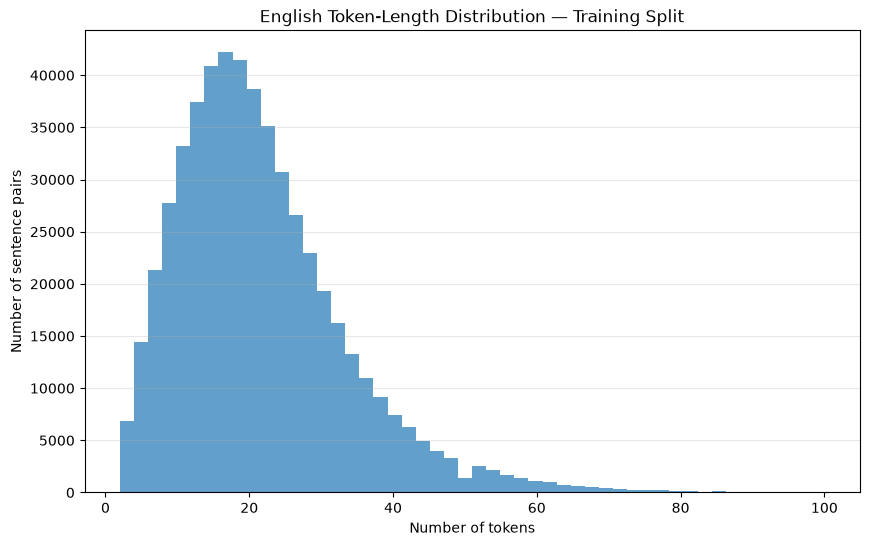

In [34]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["eng_token_length"],
    bins=50,
    alpha=0.7,
)

plt.title("English Token-Length Distribution — Training Split")
plt.xlabel("Number of tokens")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Plot Amharic token-length distributions

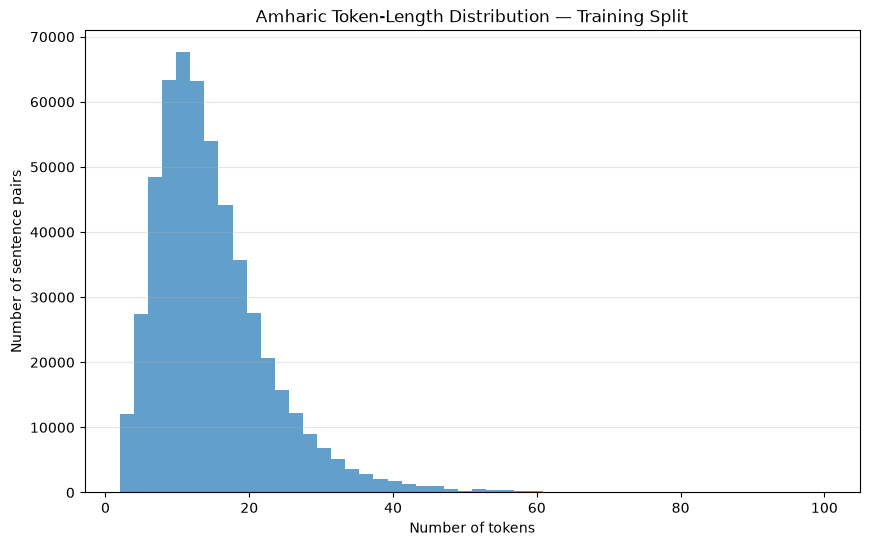

In [35]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["amh_token_length"],
    bins=50,
    alpha=0.7,
)

plt.title("Amharic Token-Length Distribution — Training Split")
plt.xlabel("Number of tokens")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Compare English and Amharic lengths

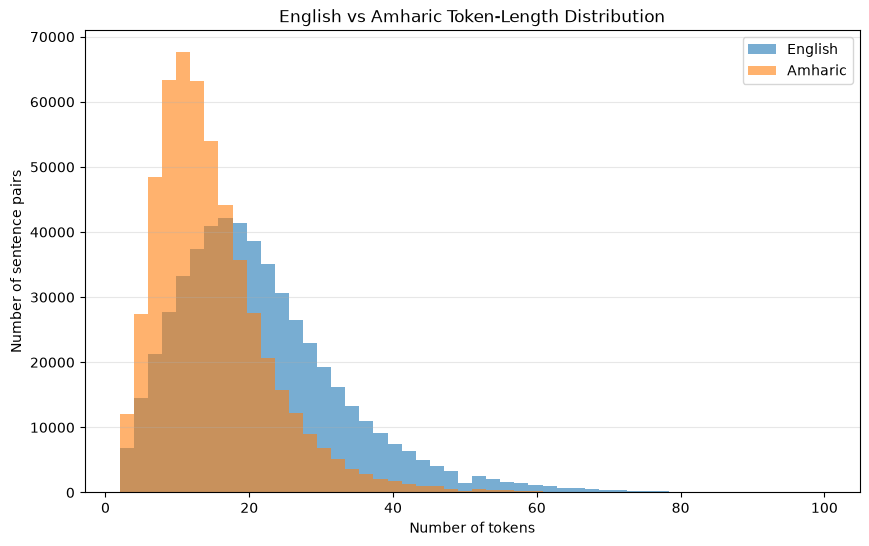

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["eng_token_length"],
    bins=50,
    alpha=0.6,
    label="English",
)

plt.hist(
    train_df["amh_token_length"],
    bins=50,
    alpha=0.6,
    label="Amharic",
)

plt.title("English vs Amharic Token-Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Calculate maximum lengths

In [37]:
max_lengths = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "English max tokens": [
            train_df["eng_token_length"].max(),
            validation_df["eng_token_length"].max(),
            test_df["eng_token_length"].max(),
        ],
        "Amharic max tokens": [
            train_df["amh_token_length"].max(),
            validation_df["amh_token_length"].max(),
            test_df["amh_token_length"].max(),
        ],
    }
)

max_lengths

,Split,English max tokens,Amharic max tokens
0,Train,100,100
1,Validation,100,100
2,Test,100,100


### Calculate recommended sequence lengths

In [38]:
recommended_lengths = pd.DataFrame(
    {
        "Language": ["English", "Amharic"],
        "P95": [
            train_df["eng_token_length"].quantile(0.95),
            train_df["amh_token_length"].quantile(0.95),
        ],
        "P99": [
            train_df["eng_token_length"].quantile(0.99),
            train_df["amh_token_length"].quantile(0.99),
        ],
        "Maximum": [
            train_df["eng_token_length"].max(),
            train_df["amh_token_length"].max(),
        ],
    }
)

recommended_lengths

,Language,P95,P99,Maximum
0,English,44.0,60.0,100
1,Amharic,30.0,44.0,100


### Count sentences above candidate limits

In [39]:
candidate_limits = [20, 30, 40, 50, 60, 80, 100]

limit_rows = []

for limit in candidate_limits:
    english_above = (
        train_df["eng_token_length"] > limit
    ).sum()

    amharic_above = (
        train_df["amh_token_length"] > limit
    ).sum()

    limit_rows.append(
        {
            "Max tokens": limit,
            "English above limit": int(english_above),
            "Amharic above limit": int(amharic_above),
            "English percentage": (
                english_above / len(train_df) * 100
            ),
            "Amharic percentage": (
                amharic_above / len(train_df) * 100
            ),
        }
    )

limit_analysis = pd.DataFrame(limit_rows)

limit_analysis

,Max tokens,English above limit,Amharic above limit,English percentage,Amharic percentage
0,20,244646,99715,46.160319,18.814435
1,30,100386,25381,18.941041,4.788940
2,40,37636,7492,7.101239,1.413606
3,50,14046,2772,2.650229,0.523027
4,60,5174,957,0.976241,0.180569
5,80,692,159,0.130568,0.030000
6,100,0,0,0.000000,0.000000


### Verify sentence counts are unchanged

In [40]:
expected_sizes = {
    "Train": 529_992,
    "Validation": 66_249,
    "Test": 66_250,
}

actual_sizes = {
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df),
}

print("Expected sizes:", expected_sizes)
print("Actual sizes  :", actual_sizes)

assert actual_sizes == expected_sizes

print("Sentence counts are unchanged")

Expected sizes: {'Train': 529992, 'Validation': 66249, 'Test': 66250}
Actual sizes  : {'Train': 529992, 'Validation': 66249, 'Test': 66250}
Sentence counts are unchanged


### Verify source-target alignment

In [41]:
for name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    assert len(dataframe["eng"]) == len(dataframe["amh"])
    assert dataframe["eng"].notna().all()
    assert dataframe["amh"].notna().all()

    print(f"{name}: source-target alignment verified")

Train: source-target alignment verified
Validation: source-target alignment verified
Test: source-target alignment verified


### Inspect random tokenized sentence pairs

In [42]:
sample = train_df.sample(
    n=5,
    random_state=123
)

for _, row in sample.iterrows():
    english_tokens = tokenizer.tokenize(row["eng"])
    amharic_tokens = tokenizer.tokenize(row["amh"])

    print("English sentence:")
    print(row["eng"])

    print("English tokens:")
    print(english_tokens)

    print("\nAmharic sentence:")
    print(row["amh"])

    print("Amharic tokens:")
    print(amharic_tokens)

    print("\n" + "-" * 80 + "\n")

English sentence:
Sound advice is found in the wisdom of Solomon , who wrote : " Anyone inexperienced puts faith in every word , but the shrewd one considers his steps . " - Proverbs 14 : 15 .
English tokens:
['Sound', 'advice', 'is', 'found', 'in', 'the', 'wisdom', 'of', 'Solomon', ',', 'who', 'wrote', ':', '"', 'Anyone', 'inexperienced', 'puts', 'faith', 'in', 'every', 'word', ',', 'but', 'the', 'shrewd', 'one', 'considers', 'his', 'steps', '.', '"', '-', 'Proverbs', '14', ':', '15', '.']

Amharic sentence:
ሰለሞን " ተላላ ሰው ሁሉን ያምናል ፤ አስተዋይ ግን ርምጃውን ያስተውላል " ሲል ጥበብ ያዘለ ምክር አስፍሯል ። - ምሳሌ 14 : 15
Amharic tokens:
['ሰለሞን', '"', 'ተላላ', 'ሰው', 'ሁሉን', 'ያምናል', '፤', 'አስተዋይ', 'ግን', 'ርምጃውን', 'ያስተውላል', '"', 'ሲል', 'ጥበብ', 'ያዘለ', 'ምክር', 'አስፍሯል', '።', '-', 'ምሳሌ', '14', ':', '15']

--------------------------------------------------------------------------------

English sentence:
And what happens after death ? ' he wondered .
English tokens:
['And', 'what', 'happens', 'after', 'death', '?', "'", 'he', 'w

### Check tokenization determinism

In [43]:
sample_texts = train_df["eng"].head(100).tolist()

first_result = tokenizer.tokenize_batch(sample_texts)
second_result = tokenizer.tokenize_batch(sample_texts)

assert first_result == second_result

print("Tokenization is deterministic")

Tokenization is deterministic


### Final notebook quality gate

In [44]:
for name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    assert dataframe["eng"].notna().all()
    assert dataframe["amh"].notna().all()

    assert (dataframe["eng_token_length"] > 0).all()
    assert (dataframe["amh_token_length"] > 0).all()

    assert len(dataframe["eng"]) == len(dataframe["amh"])

print("=" * 70)
print("TOKENIZATION ANALYSIS COMPLETE")
print("=" * 70)
print("All split sizes preserved.")
print("All source-target pairs remain aligned.")
print("No zero-length tokenized sentences found.")
print("Token-length statistics calculated.")
print("Tokenization analysis quality gate passed.")

TOKENIZATION ANALYSIS COMPLETE
All split sizes preserved.
All source-target pairs remain aligned.
No zero-length tokenized sentences found.
Token-length statistics calculated.
Tokenization analysis quality gate passed.


### Save the analysis results

In [45]:
REPORTS_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

token_length_comparison.to_csv(
    REPORTS_DIR / "token_length_comparison.csv",
    index=False,
)

recommended_lengths.to_csv(
    REPORTS_DIR / "recommended_sequence_lengths.csv",
    index=False,
)

limit_analysis.to_csv(
    REPORTS_DIR / "token_length_limit_analysis.csv",
    index=False,
)

print("Tokenization analysis tables saved.")

Tokenization analysis tables saved.
